Final Weights: [0.3 0.6]
Final Bias: -0.8999999999999999


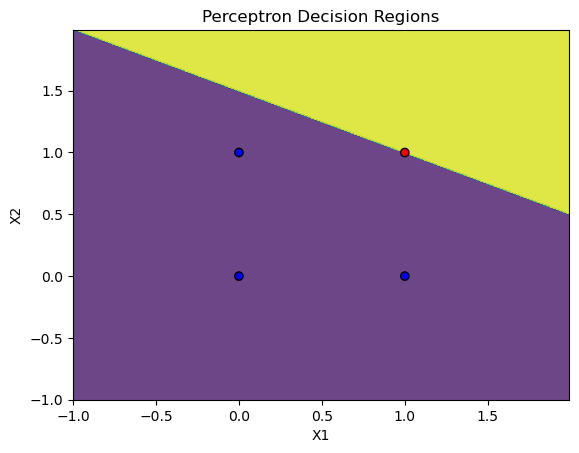

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Training Data (AND Gate)
X = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
Y = np.array([-1, -1, -1, 1])

# Step 2: Initialize weights and bias
w = np.zeros(X.shape[1])
b = 0
lr = 0.3   # learning rate

# Step 3: Training (Perceptron Learning)
for epoch in range(6):
    for i in range(X.shape[0]):
        
        # Prediction
        yin = np.dot(X[i], w) + b
        y_pred = 1 if yin >= 0 else -1
        
        # Update if wrong
        if y_pred != Y[i]:
            w = w + lr * Y[i] * X[i]
            b = b + lr * Y[i]

print("Final Weights:", w)
print("Final Bias:", b)


# Step 4: Create mesh grid for decision region
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Step 5: Predict for all grid points
Z = np.array([
    1 if np.dot([x1, x2], w) + b >= 0 else -1
    for x1, x2 in zip(xx.ravel(), yy.ravel())
])
Z = Z.reshape(xx.shape)

# Step 6: Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.8)

# Plot training points
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr', edgecolors='k')

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Perceptron Decision Regions")
plt.show()